In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

### Loading the Data

In [2]:
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
df = pd.read_csv(f"C:/Users/caleb/Downloads/archive/creditcard.csv")

In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


### Summarizing the Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

There are no missing values. The data types also look correct for every feature except "Time", which should be treated as an integer or datetime instead.

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Identifying Duplicates

In [6]:
# Identify any identical rows
duplicates = df[df.duplicated(keep=False)]
duplicates

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284190,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0
284192,172233.0,-2.691642,3.123168,-3.339407,1.017018,-0.293095,-0.167054,-0.745886,2.325616,-1.634651,...,0.402639,0.259746,-0.086606,-0.097597,0.083693,-0.453584,-1.205466,-0.213020,36.74,0


<Axes: >

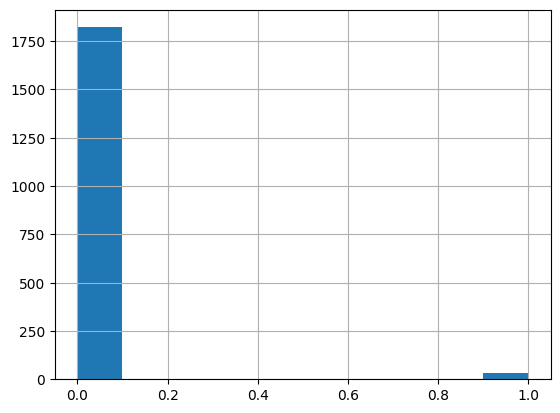

In [7]:
duplicates['Class'].hist()

In [8]:
len(duplicates[duplicates['Class'] == 1])

32

In [9]:
len(df[df['Class'] == 1])

492

In [10]:
32 / 492

0.06504065040650407

If we remove the duplicates it would result in losing 6% of the positive class (fraudulent charges). I will take the assumption that it is important to keep all these transactions instead of removing them. It is worth further investigation as to why there could be duplicate rows (especially with identical timestamps)

As discussed in the documentation, the features V1-V28 are the result of PCA transformation of the original data to protect client confidentiality. Time, Amount, and Class are the other features, which all have different scales. Class is the intended target variable.

### Identifying Inconsistent Data

#### Amounts

In [11]:
df['Amount'].min(), df['Amount'].max()

(np.float64(0.0), np.float64(25691.16))

In [12]:
len(df[df['Amount'] == 0])

1825

In [13]:
len(df[df['Amount'] == 25691.16])

1

<Axes: >

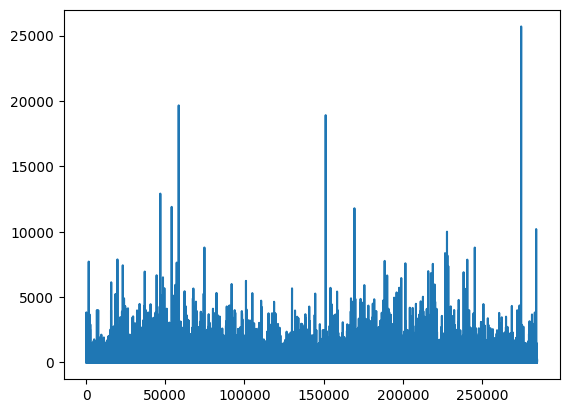

In [14]:
# Check whether any invalid amounts are present
df['Amount'].plot()

The smallest amount is 0 and the max is 25,691.16. The largest Amount seems huge for a single credit card transaction, but since there are many it seems valid. The minimum of 0 seems unlikely as well, but it could be a charge to check a card is active. I am assuming they are valid as well.

#### Labels

In [15]:
df['Class'].unique()

array([0, 1])

The target looks good. It only has values 0 and 1.

#### Time

<Axes: >

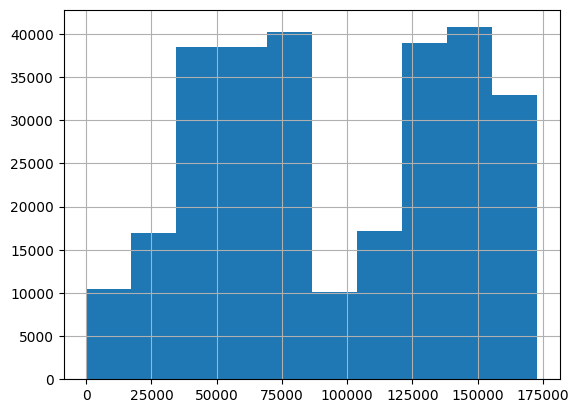

In [16]:
df['Time'].hist()

Interestingly, we can see that most of the instances are in the time range 30,000 - 85,000 and 120,000 - 175,000

### Confirming Class Imbalance

<Axes: >

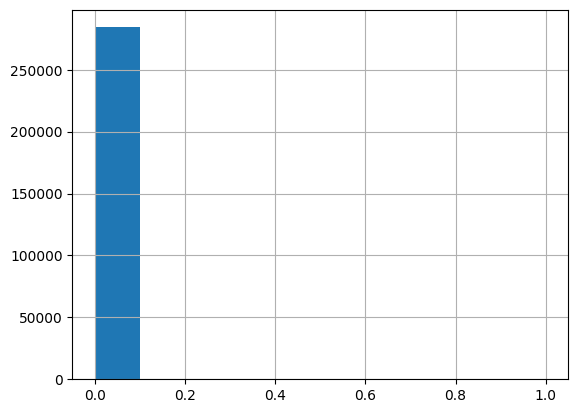

In [17]:
df['Class'].hist()

In [18]:
len(df[df['Class'] == 1])

492

It is clear there is a huge class imbalance for the target variable (as is typical for fraud datasets). We will have to consider this throughout the project.

## Outliers

<Axes: >

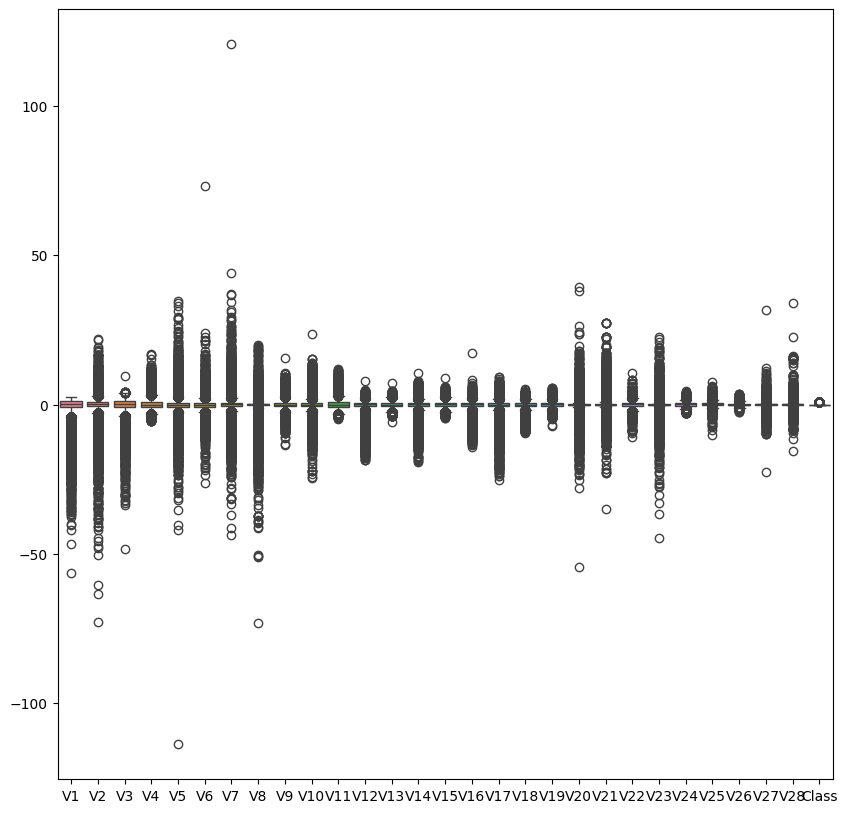

In [19]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(df.drop(columns=['Time', 'Amount']), ax=ax)

<Axes: >

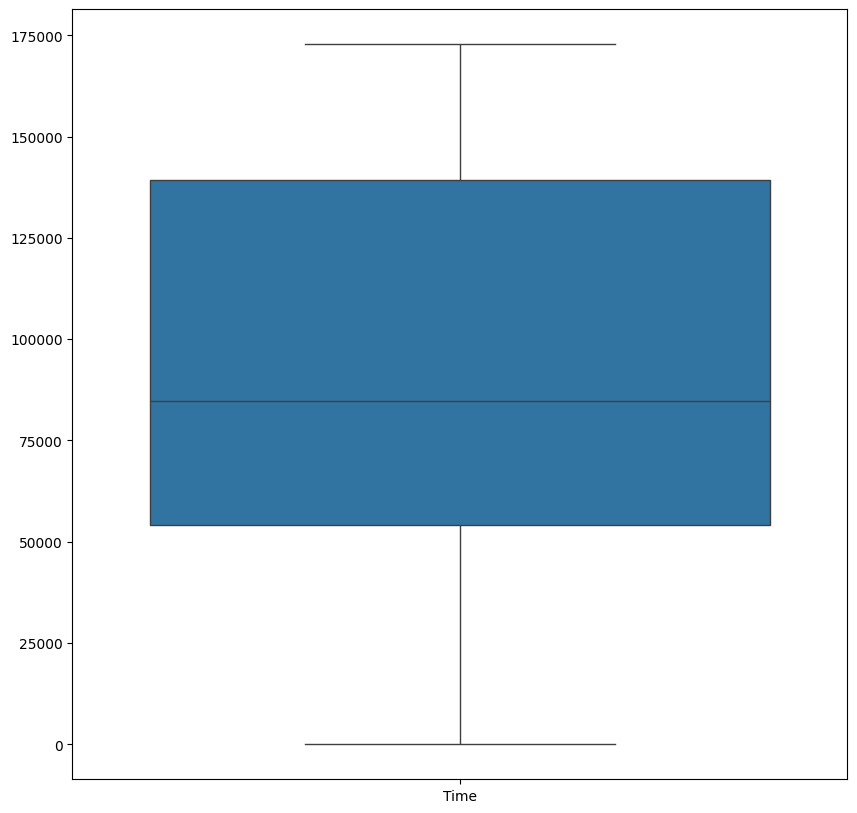

In [20]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(df[['Time']], ax=ax)

<Axes: >

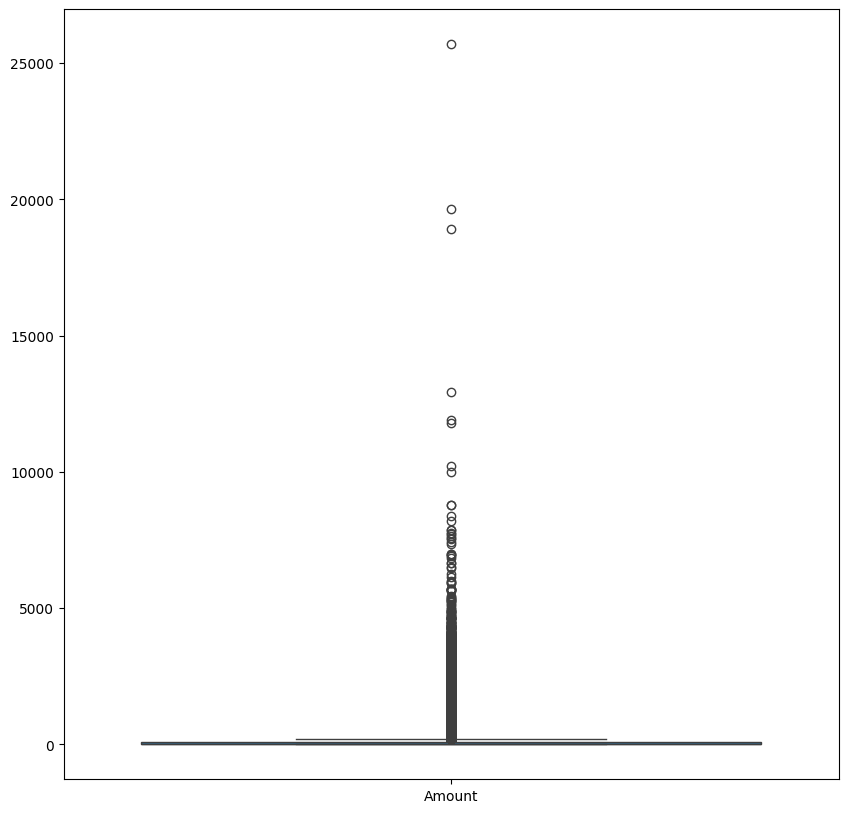

In [21]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(df[['Amount']], ax=ax)

### Conclusions

The data is mostly clean. There are duplicates in the dataset, which may need to be handled. Additionally, some of these duplicates have target value equal to 1. Since there is class imbalance for the target, we need to be careful with handling these duplicates. For the data, the transaction amounts do not have any strange or inconsistent data. Every value in this feature is numeric and positive. Additionally, all of the Time feature are positive, indicating the instances are recorded after the first record. We do see a few areas of the Time distribution which are dense, which could be interesting to explore further.

## Univariate Analysis

#### Histograms

C:\Users\caleb\AppData\Local\Temp\ipykernel_2300\3476324748.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(bins=30, ax=ax)


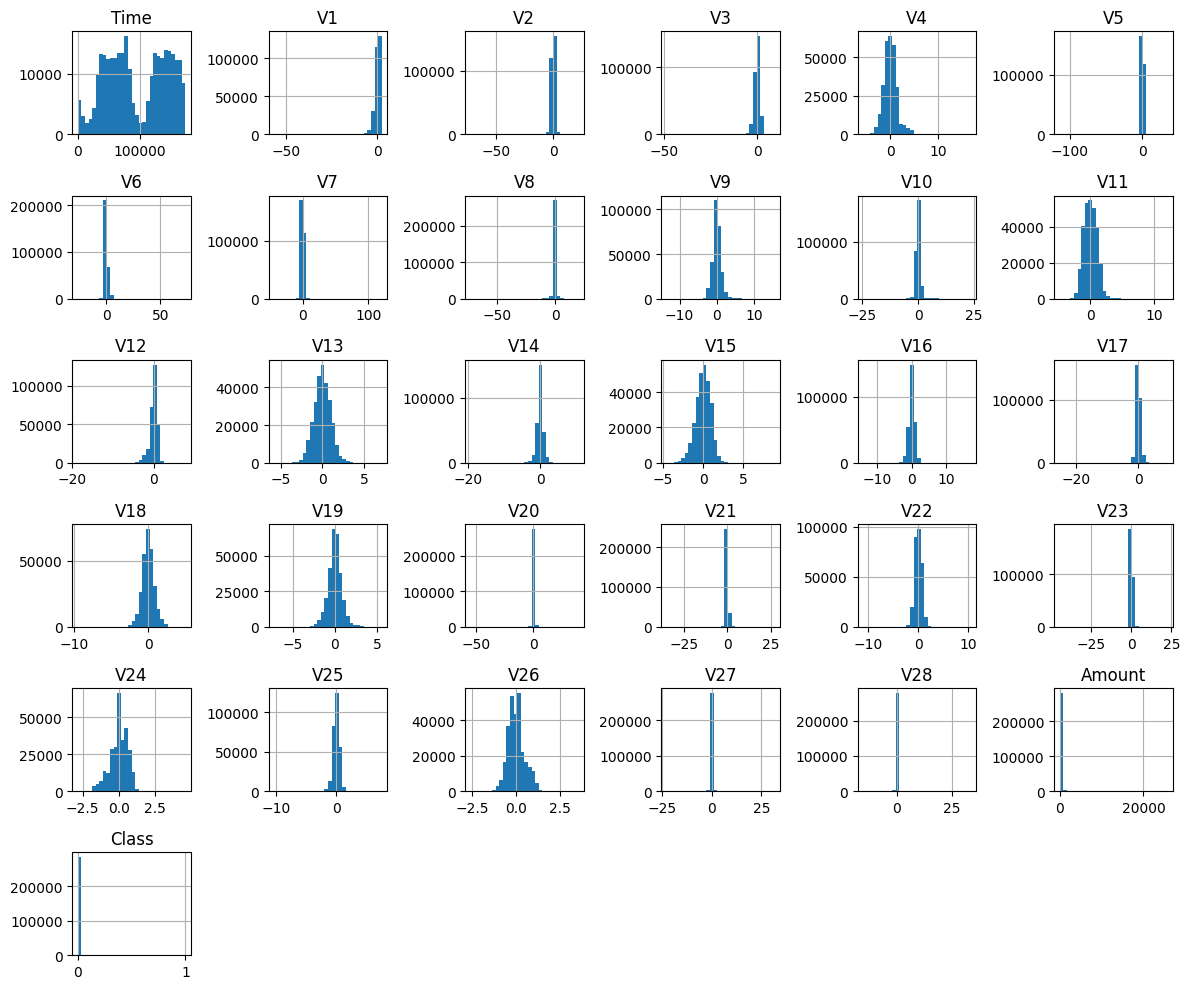

In [38]:
fig, ax = plt.subplots(figsize=(12,10))
df.hist(bins=30, ax=ax)
plt.tight_layout()
plt.savefig('credit_card_figs/histograms.png')
None

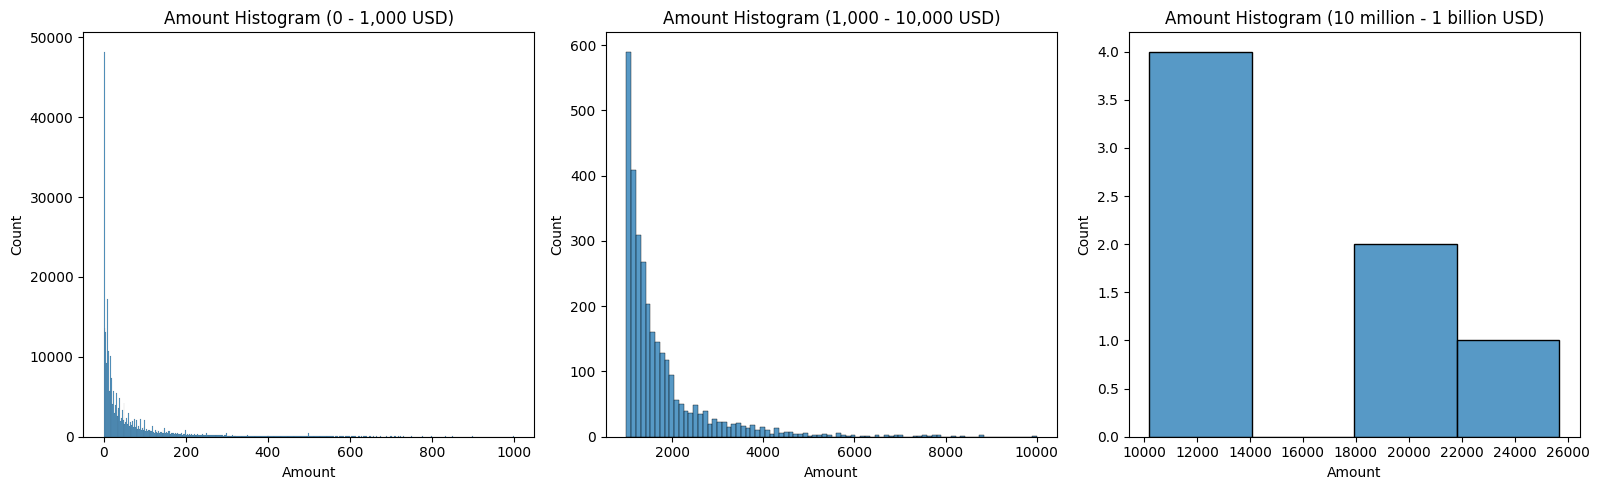

In [35]:
# fig, ax = plt.subplots(figsize=(12,10))
# sns.histplot(df[df['Amount'] < 1000]['Amount'], bins=30, ax=ax)
# plt.tight_layout()
# plt.savefig('credit_card_figs/histograms.png')
# None

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
sns.histplot(data=df[df['Amount'].between(0, 1_000)], x="Amount", ax=ax1)
ax1.set_title("Amount Histogram (0 - 1,000 USD)")
sns.histplot(data=df[df['Amount'].between(1_000, 10_000)], x="Amount", ax=ax2)
ax2.set_title("Amount Histogram (1,000 - 10,000 USD)")
sns.histplot(data=df[df['Amount'] > 10_000], x="Amount", ax=ax3)
ax3.set_title("Amount Histogram (10 million - 1 billion USD)")

plt.tight_layout()
# plt.savefig("ibm_figs/amount_paid_hist.png")
None

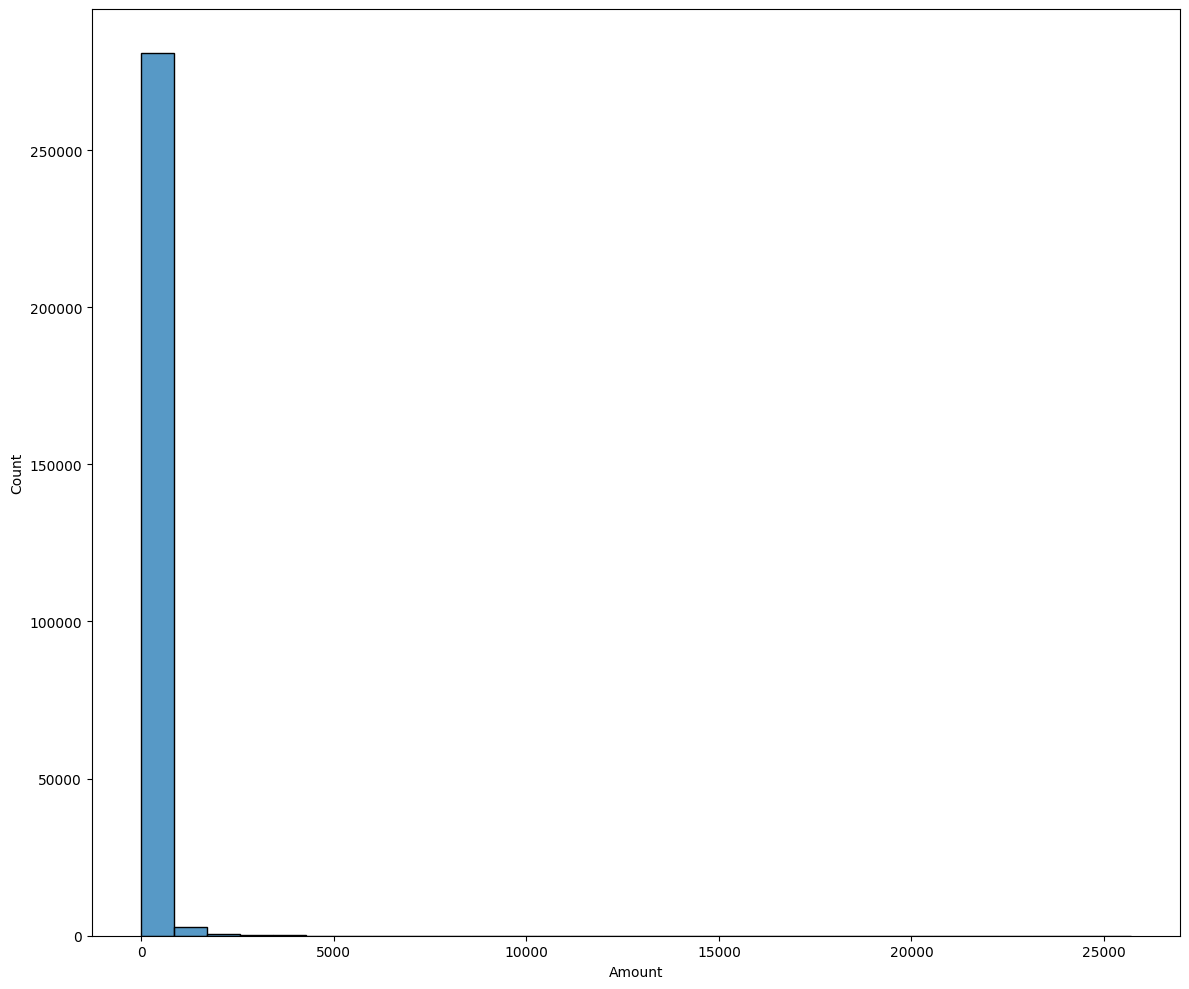

In [39]:
fig, ax = plt.subplots(figsize=(12,10))
sns.histplot(df['Amount'], bins=30, ax=ax)
plt.tight_layout()
plt.savefig('credit_card_figs/amount_histograms.png')
None

## Bivariate Analysis

#### Correlations

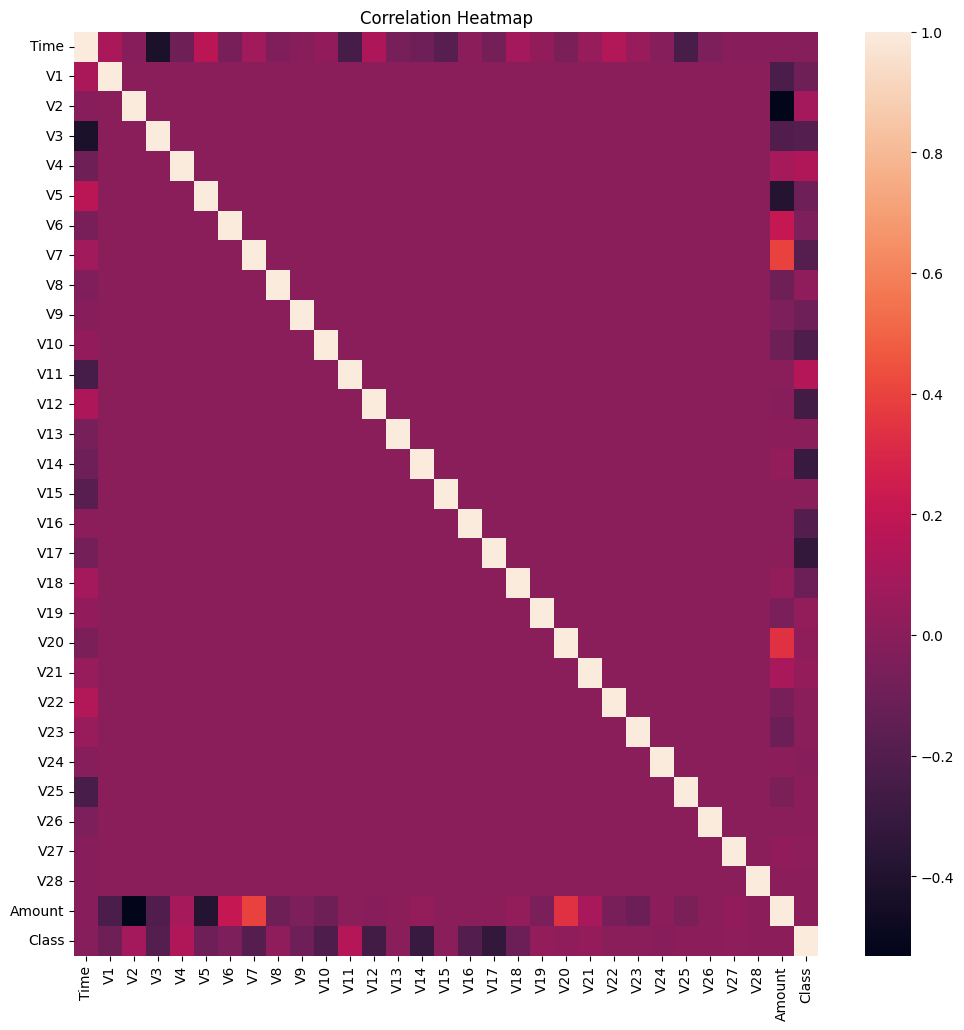

In [44]:
plt.figure(figsize=(12, 12)) # Adjust the width and height as needed
sns.heatmap(df.corr(numeric_only=True))
plt.title("Correlation Heatmap")
plt.savefig("credit_card_figs/correlation.png", bbox_inches='tight')

In [49]:
df_pos = df[df['Class'] == 1]
df_neg = df[df['Class'] == 0]

# Sample from the majority class to reach your desired balance
# Adjust n or fraction as needed
df_neg_sample = df_neg.sample(n=len(df_pos)) 

# Combine and shuffle
balanced_df = pd.concat([df_pos, df_neg_sample]).sample(frac=1)

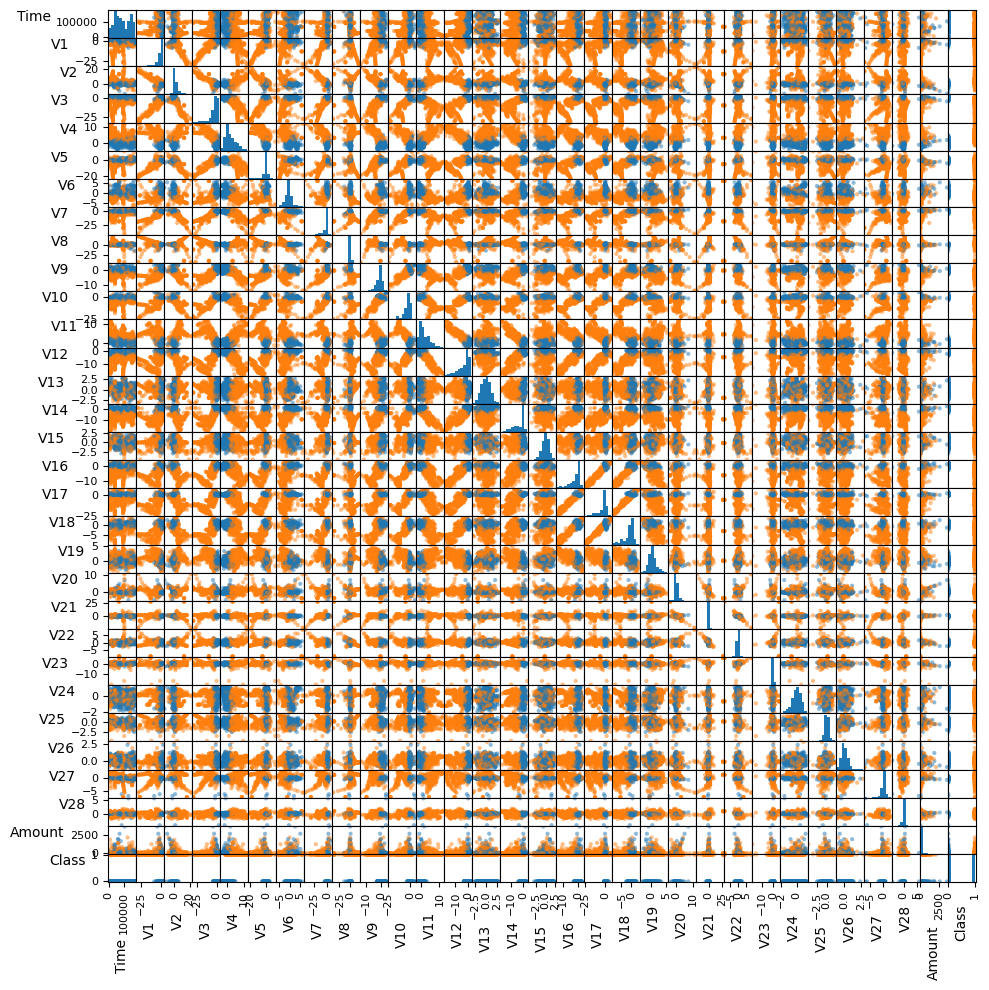

In [51]:
df_colored = balanced_df.copy()
df_colored["color"] = df_colored["Class"].map(
    dict(
        zip(df_colored['Class'].unique(), plt.rcParams['axes.prop_cycle'].by_key()['color'])
    )
) 

# Commenting this code since it slows down execution significantly. The output can be viewed in the scatter_matrix.png figure
axes = pd.plotting.scatter_matrix(df_colored, color=df_colored['color'], figsize=(10,10))
# text rotation snippet from https://stackoverflow.com/questions/58623528/pandas-scatter-matrix-labels-vertical-x-and-horizontal-y-without-being-cut
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.savefig('credit_card_figs/scatter_matrix.png')

# img = mpimg.imread('scatter_matrix.png')
# plt.imshow(img)
# plt.axis('off')
None

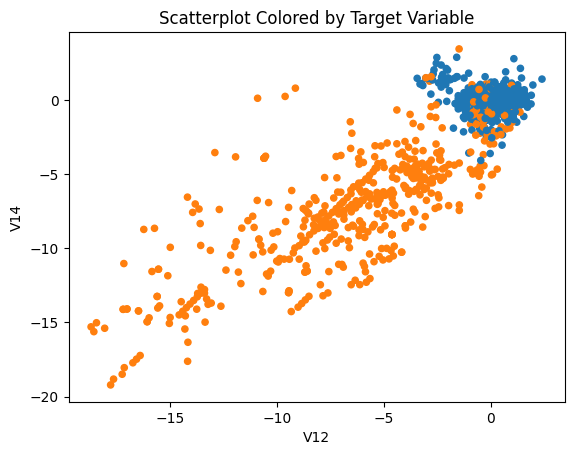

In [60]:
_ = df_colored.plot.scatter("V12", "V14", c="color")
plt.title("Scatterplot Colored by Target Variable")
plt.savefig("credit_card_figs/scatter_v12_v14")
None

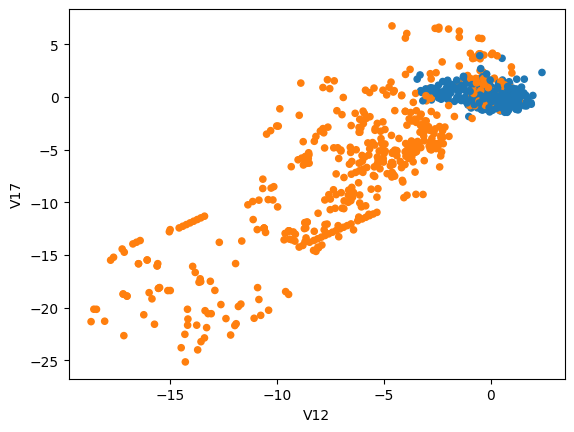

In [54]:
_ = df_colored.plot.scatter("V12", "V17", c="color")

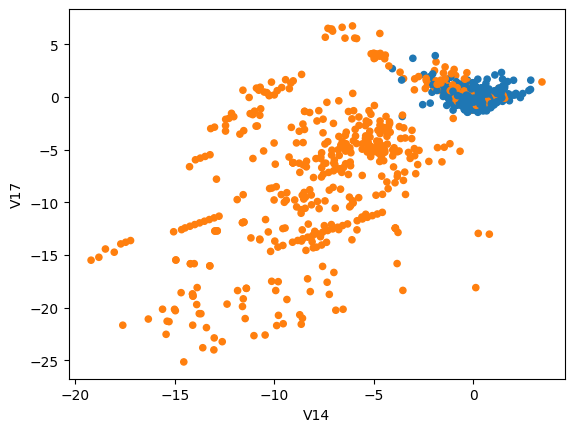

In [55]:
_ = df_colored.plot.scatter("V14", "V17", c="color")

<Axes: ylabel='Amount'>

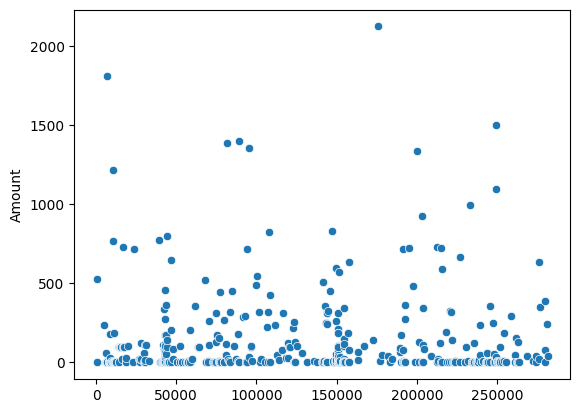

In [40]:
sns.scatterplot(df[df['Class'] == 1]['Amount'])

<Axes: ylabel='Amount'>

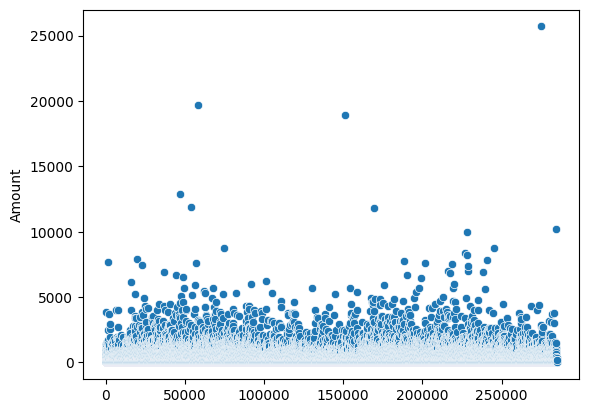

In [41]:
sns.scatterplot(df['Amount'])